<a href="https://colab.research.google.com/github/shahadalmutairi863/arabic-dialect-classification/blob/main/MARBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Installing the necessary packages

In [ ]:
! pip install arabert
! pip install transformers
! pip install farasapy
! pip install pyarabic

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.0/185.0 kB 7.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 11.1 MB/s eta 0:00:00
  Created wheel for emoji: filename=emoji-1.4.2-py3-none-any.whl size=186456 sha256=d4d8f23357d6611e11aeb27f278c2dc275bf0e50c5c1a671a2be644c7818eb7c
  Stored in directory: /root/.cache/pip/wheels/94/08/b4/78657b1541bb704b088317b52429ee4016d9888fe47dbb130f
Successfully built emoji


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Arabic_Dialect_Classification/cleaned_dataset.csv", engine="python")

In [ ]:
data

,Cleaned_text,SpeakerDialect
0,وضح كلامك يا مغيث,Najdi
1,تري راسي ما عاد يتحمل الغازك,Najdi
2,سلامه راسك يا ابو مسامح,Najdi
3,ما يصير يا ابو مسامح تخلي البنت في البيت دون ...,Najdi
4,ويش فيها لقعدت في البيت دون امها ما هو ده بيت...,Najdi
...,...,...
241828,لازم تشيلها عشان تصير سعيد في حياتك,Najdi
241829,انا سويت كل هذا علي شانك لا واله مريم مريم عط...,More than 1 speaker اكثر من متحدث
241830,مريم,Najdi
241831,لا لا,Najdi


In [ ]:
data

,Cleaned_text,SpeakerDialect
0,وضح كلامك يا مغيث,Najdi
1,تري راسي ما عاد يتحمل الغازك,Najdi
2,سلامه راسك يا ابو مسامح,Najdi
3,ما يصير يا ابو مسامح تخلي البنت في البيت دون ...,Najdi
4,ويش فيها لقعدت في البيت دون امها ما هو ده بيت...,Najdi
...,...,...
241828,لازم تشيلها عشان تصير سعيد في حياتك,Najdi
241829,انا سويت كل هذا علي شانك لا واله مريم مريم عط...,More than 1 speaker اكثر من متحدث
241830,مريم,Najdi
241831,لا لا,Najdi


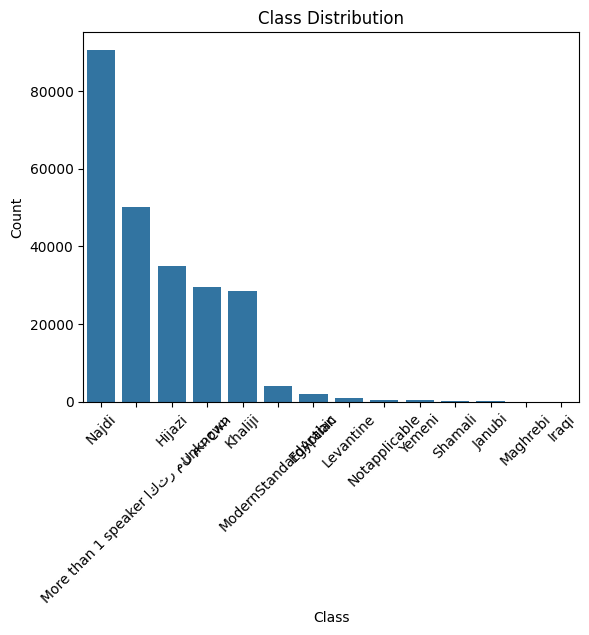

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count the occurrences of each class in your dataset
label_counts = data['SpeakerDialect'].value_counts()  # Replace 'label' with your actual column name

# Plot the distribution
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.xticks(rotation=45)  # Rotate labels if necessary
plt.show()


In [ ]:
data

,Cleaned_text,SpeakerDialect
0,وضح كلامك يا مغيث,Najdi
1,تري راسي ما عاد يتحمل الغازك,Najdi
2,سلامه راسك يا ابو مسامح,Najdi
3,ما يصير يا ابو مسامح تخلي البنت في البيت دون ...,Najdi
4,ويش فيها لقعدت في البيت دون امها ما هو ده بيت...,Najdi
...,...,...
241828,لازم تشيلها عشان تصير سعيد في حياتك,Najdi
241829,انا سويت كل هذا علي شانك لا واله مريم مريم عط...,More than 1 speaker اكثر من متحدث
241830,مريم,Najdi
241831,لا لا,Najdi


In [ ]:
data["SpeakerDialect"].unique()


array(['Najdi', 'More than 1 speaker اكثر من متحدث', 'Unknown', 'Khaliji',
       'Hijazi', 'ModernStandardArabic', 'Notapplicable', 'Egyptian',
       'Levantine', 'Yemeni', 'Maghrebi', 'Janubi', 'Shamali', 'Iraqi'],
      dtype=object)

In [ ]:
# Mapping dialects to numbers
map_label = {
    'Najdi': 0,
    'More than 1 speaker اكثر من متحدث': 1,
    'Unknown': 2,
    'Khaliji': 3,
    'Hijazi': 4,
    'ModernStandardArabic': 5,
    'Notapplicable': 6,
    'Egyptian': 7,
    'Levantine': 8,
    'Yemeni': 9,
    'Maghrebi': 10,
    'Janubi': 11,
    'Shamali': 12,
    'Iraqi': 13
}

# Mapping numbers back to dialects
label_map = {v: k for k, v in map_label.items()}
data['SpeakerDialect'] = data['SpeakerDialect'].map(map_label)

print(map_label)
print(label_map)


{'Najdi': 0, 'More than 1 speaker اكثر من متحدث': 1, 'Unknown': 2, 'Khaliji': 3, 'Hijazi': 4, 'ModernStandardArabic': 5, 'Notapplicable': 6, 'Egyptian': 7, 'Levantine': 8, 'Yemeni': 9, 'Maghrebi': 10, 'Janubi': 11, 'Shamali': 12, 'Iraqi': 13}
{0: 'Najdi', 1: 'More than 1 speaker اكثر من متحدث', 2: 'Unknown', 3: 'Khaliji', 4: 'Hijazi', 5: 'ModernStandardArabic', 6: 'Notapplicable', 7: 'Egyptian', 8: 'Levantine', 9: 'Yemeni', 10: 'Maghrebi', 11: 'Janubi', 12: 'Shamali', 13: 'Iraqi'}


In [ ]:
data

,Cleaned_text,SpeakerDialect
0,وضح كلامك يا مغيث,Najdi
1,تري راسي ما عاد يتحمل الغازك,Najdi
2,سلامه راسك يا ابو مسامح,Najdi
3,ما يصير يا ابو مسامح تخلي البنت في البيت دون ...,Najdi
4,ويش فيها لقعدت في البيت دون امها ما هو ده بيت...,Najdi
...,...,...
241828,لازم تشيلها عشان تصير سعيد في حياتك,Najdi
241829,انا سويت كل هذا علي شانك لا واله مريم مريم عط...,More than 1 speaker اكثر من متحدث
241830,مريم,Najdi
241831,لا لا,Najdi


In [ ]:
from transformers import AutoTokenizer
model_name="UBC-NLP/MARBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/376 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.10M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
from sklearn.model_selection import train_test_split
# Rename columns if necessary
data = data.rename(columns={'SpeakerDialect': 'dialect', 'Cleaned_text': 'text'})


In [ ]:
data

,Cleaned_text,SpeakerDialect
0,وضح كلامك يا مغيث,Najdi
1,تري راسي ما عاد يتحمل الغازك,Najdi
2,سلامه راسك يا ابو مسامح,Najdi
3,ما يصير يا ابو مسامح تخلي البنت في البيت دون ...,Najdi
4,ويش فيها لقعدت في البيت دون امها ما هو ده بيت...,Najdi
...,...,...
241828,لازم تشيلها عشان تصير سعيد في حياتك,Najdi
241829,انا سويت كل هذا علي شانك لا واله مريم مريم عط...,More than 1 speaker اكثر من متحدث
241830,مريم,Najdi
241831,لا لا,Najdi


In [ ]:
data

,text,dialect
0,وضح كلامك يا مغيث,Najdi
1,تري راسي ما عاد يتحمل الغازك,Najdi
2,سلامه راسك يا ابو مسامح,Najdi
3,ما يصير يا ابو مسامح تخلي البنت في البيت دون ...,Najdi
4,ويش فيها لقعدت في البيت دون امها ما هو ده بيت...,Najdi
...,...,...
241828,لازم تشيلها عشان تصير سعيد في حياتك,Najdi
241829,انا سويت كل هذا علي شانك لا واله مريم مريم عط...,More than 1 speaker اكثر من متحدث
241830,مريم,Najdi
241831,لا لا,Najdi


In [ ]:
# Split into train (80%) and test (20%)
dataset, test_data = train_test_split(data, test_size=0.2, random_state=42, stratify=data['dialect'])

# Display dataset shapes
print("Train set size:", dataset.shape)
print("Test set size:", test_data.shape)

Train set size: (193466, 2)
Test set size: (48367, 2)


In [ ]:
dataset

,text,dialect
70238,حنضبطه بس,Najdi
99201,ويشقي ويتعب علشان يجمع شي بعيله الي من اله اخ...,More than 1 speaker اكثر من متحدث
134830,امرك سيدي المنظم خدو ودوه داخل السجن امرك سيد...,More than 1 speaker اكثر من متحدث
76711,غير واضح هذا ال,Khaliji
118122,بحط كدا زعتر او خبز مقلي الي تحبون انا حاطه خ...,Najdi
...,...,...
201450,بابا نعم عرفت تحل مساله الرياضيات لا بحلها بي...,More than 1 speaker اكثر من متحدث
41312,وانا جيتك اخطب بنتك فاطمه اه واله ان نسبكم يش...,More than 1 speaker اكثر من متحدث
153933,لا سعيد لا تخاف نحنا مع بعض رايحين نساعد بعض ...,More than 1 speaker اكثر من متحدث
221728,كيف عرفت,ModernStandardArabic


In [ ]:
test_data=test_data[test_data['dialect'].isnull()==False]
dataset=dataset[dataset['dialect'].isnull()==False]

In [ ]:
dataset = dataset[dataset["text"].notna() & (dataset["text"].str.strip() != "")]
test_data = test_data[test_data["text"].notna() & (test_data["text"].str.strip() != "")]


In [ ]:
dataset

,text,dialect
133041,روح لامك روح,3
234955,ولا رز عرسنا ودقوا ومثل ما قلت واله ما تدق ول...,2
25268,فكري هذا كرتي معك اذا غيرتي رايك,0
112450,ونحط لا اصبر لا نسي لا الخبط نبي روزميري,0
174569,اقول لك لا تنكدين عليا انا دحين بالي مشغول مع...,4
...,...,...
54706,ايه عشان كذه جيت اليوم شاركتي ليوه مين الي مع...,0
112367,هذي المده تكون كافيتك انه الباذنجان يطلع الما...,0
61549,تستاهل يا عمي لا اسمع عليه اسمع اسمع مني اسمع...,1
29809,عفوا ماذا قلت هاهاها الم اقول لكم,1


In [ ]:
print(dataset['dialect'].value_counts())


dialect
0     72482
1     40103
4     27845
2     23471
3     22786
5      3269
7      1622
8       754
6       311
9       302
12      101
11       82
10       33
13        2
Name: count, dtype: int64


In [ ]:
# Initialize AraBERT Preprocessor
from arabert.preprocess import ArabertPreprocessor
model_name1 = "aubmindlab/bert-base-arabert"
arabert_prep = ArabertPreprocessor(model_name=model_name1)


/usr/local/lib/python3.11/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'farasa-api.qcri.org'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


100%|██████████| 241M/241M [09:06<00:00, 441kiB/s]


[2025-05-09 19:30:06,648 - farasapy_logger - WARNING]: Be careful with large lines as they may break on interactive mode. You may switch to Standalone mode for such cases.


In [ ]:
dataset["text"]=dataset["text"].apply(lambda x:arabert_prep.preprocess(x))

In [ ]:
test_data["text"]=test_data["text"].apply(lambda x:arabert_prep.preprocess(x))

In [ ]:
dataset

,text,dialect
133041,روح ل+ أم ك+ روح,3
234955,و+ لا رز عرس +نا و+ دق +وا و+ مثل ما قل +ت و+ ...,2
25268,فكري هذا ك+ رتي مع ك+ اذ +ا غير +ت +ي راي ك+,0
112450,و+ نحط لا اصبر لا نسي لا ال+ خبط نبي روزميري,0
174569,أقول ل+ ك+ لا تنكد +ين عليا أنا دح +ين بالي مش...,4
...,...,...
54706,أي عشان كذ +ه جيت ال+ يوم شارك +ت +ي ل+ يو +ه ...,0
112367,هذي ال+ مده تكون كافي +ت ك+ +ان +ه ال+ باذنجان...,0
61549,تستاهل يا عمي لا أسمع علي +ه أسمع أسمع من +ي أ...,1
29809,عفو +ا ماذا قل +ت هاها +ها الم أقول ل+ +كم,1


In [ ]:
test_data


,text,dialect
178052,لحظ +ه اركب فين أنا ما اركب مع ناس ما اعرف +هم,4
87880,حمل غير واضح مشروع ال+ حمد ل+ +ه وطني كبير مع ...,0
226366,كذا يا بكر كذا يعني هذا الي اتفق +نا أنا و+ يا ك+,0
68871,زيد,0
70015,ال+ حين حنبدا نشيل ال+ بصل و+ نحط ال+ بهار +ات...,0
...,...,...
6306,و+ أنا مع +كم لا أنت بيعطونك علي ال+ غلاف هاها...,1
175934,أنا عند +ي خوي و+ ضايع +ين و+ نبي نعرف ال+ طري...,2
203700,حريم و+ رجاجيل يتحرك +ون في وسط صندوق يتحرك +و...,1
97205,يشون +ها بعد +ين حنجيب ال+ زبده الي أنا مسوي +...,0


# Importing the necessary packages

In [ ]:
from arabert.preprocess import ArabertPreprocessor
from sklearn.metrics import (accuracy_score, f1_score,recall_score)
from torch.utils.data import  Dataset
from transformers import (AutoConfig, AutoModelForSequenceClassification,
                        AutoTokenizer, BertTokenizer, Trainer,
                        TrainingArguments)
from transformers.data.processors.utils import InputFeatures

In [ ]:
#chose bert model
model_name = 'UBC-NLP/MARBERT'
#asafaya/bert-base-arabic
#UBC-NLP/ARBERT
#UBC-NLP/MARBERT
#bert-base-multilingual-uncased
num_labels = 14
max_length = 120

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(model_name)


## To work using PyTorch we need to create a classification dataset to load the data

In [ ]:
# ✅ Define classification dataset
class ClassificationDataset(Dataset):
    def __init__(self, text, target, tokenizer, max_len):
        self.text = text
        self.target = target
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.text)

    def __getitem__(self, item):
        text = str(self.text[item])
        text = " ".join(text.split())  # Normalize spaces

        inputs = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids": inputs["input_ids"].squeeze(0),
            "attention_mask": inputs["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.target[item], dtype=torch.long),
        }


In [ ]:
#dataset['dialect'] = dataset['dialect'].map(map_label)
#test_data['dialect'] = test_data['dialect'].map(map_label)


In [ ]:
#test_data=test_data[test_data['dialect'].isnull()==False]
#dataset=dataset[dataset['dialect'].isnull()==False]

In [ ]:
dataset['dialect'] = dataset['dialect'].astype(int)
test_data['dialect'] = test_data['dialect'].astype(int)

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 193163 entries, 133041 to 79822
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   text     193163 non-null  object
 1   dialect  193163 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 4.4+ MB


In [ ]:
dataset

,text,dialect
133041,روح ل+ أم ك+ روح,3
234955,و+ لا رز عرس +نا و+ دق +وا و+ مثل ما قل +ت و+ ...,2
25268,فكري هذا ك+ رتي مع ك+ اذ +ا غير +ت +ي راي ك+,0
112450,و+ نحط لا اصبر لا نسي لا ال+ خبط نبي روزميري,0
174569,أقول ل+ ك+ لا تنكد +ين عليا أنا دح +ين بالي مش...,4
...,...,...
54706,أي عشان كذ +ه جيت ال+ يوم شارك +ت +ي ل+ يو +ه ...,0
112367,هذي ال+ مده تكون كافي +ت ك+ +ان +ه ال+ باذنجان...,0
61549,تستاهل يا عمي لا أسمع علي +ه أسمع أسمع من +ي أ...,1
29809,عفو +ا ماذا قل +ت هاها +ها الم أقول ل+ +كم,1


## Creating datasets

In [ ]:
# ✅ Create datasets
train_dataset = ClassificationDataset(dataset["text"].tolist(), dataset["dialect"].tolist(), tokenizer, max_length)
test_dataset = ClassificationDataset(test_data["text"].tolist(), test_data["dialect"].tolist(), tokenizer, max_length)

print(f"✅ Train dataset size: {len(train_dataset)}")
print(f"✅ Test dataset size: {len(test_dataset)}")

✅ Train dataset size: 193163
✅ Test dataset size: 48281


In [ ]:
(len(train_dataset))

193163

## Create a function that return a pretrained model ready to do classification

In [ ]:
def model_init():
    return AutoModelForSequenceClassification.from_pretrained(model_name, return_dict=True, num_labels=num_labels)

## Metrics

In [ ]:
def compute_metrics(p): #p should be of type EvalPrediction
  preds = np.argmax(p.predictions, axis=1)
  assert len(preds) == len(p.label_ids)
  macro_f1 = f1_score(p.label_ids,preds,average='macro')
  macro_recall = recall_score(p.label_ids,preds,average='macro')
  acc = accuracy_score(p.label_ids,preds)
  return {
      'macro_f1' : macro_f1,
      'accuracy': acc,
      'recall':macro_recall
  }

## Training arguments

In [ ]:
from transformers import TrainingArguments, EarlyStoppingCallback
import torch
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Arabic_Dialect_Classification/MARBERT",
    adam_epsilon=1e-8,
    learning_rate=5e-6,
    fp16=True,  # استخدام حساب النقطة العائمة 16 بت إذا كان لديك V100/T4
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    num_train_epochs=5,
    warmup_ratio=0.1,  # استخدام Warmup لتحسين الاستقرار
    do_eval=True,
    weight_decay=0.01 ,
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=5,  # تقليل عدد النماذج المحفوظة لتوفير المساحة
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    report_to=[],
)

## Creating the trainer

In [ ]:
trainer = Trainer(
    model = model_init(),
    args = training_args,
    train_dataset = train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at UBC-NLP/MARBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Tarining

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Macro F1,Accuracy,Recall
1,1.236400,1.208918,0.199719,0.553075,0.199663
2,1.151300,1.166481,0.232210,0.571363,0.220707
3,1.099700,1.160630,0.241417,0.573766,0.227304
4,0.974100,1.197935,0.257826,0.567014,0.246276


TrainOutput(global_step=30180, training_loss=1.1392862763603924, metrics={'train_runtime': 9406.5617, 'train_samples_per_second': 102.675, 'train_steps_per_second': 3.208, 'total_flos': 5.955642348768576e+16, 'train_loss': 1.1392862763603924, 'epoch': 4.999254534912615})

## Saving the model

In [ ]:
import os
model_save_path = '/content/drive/MyDrive/Arabic_Dialect_Classification/model_checkpoint_marbert'
# Set the model configuration for label mappings
trainer.model.config.label2id = map_label
trainer.model.config.id2label = label_map
trainer.save_model(os.path.join(model_save_path, 'checkpoint-2'))
train_dataset.tokenizer.save_pretrained(os.path.join(model_save_path, 'checkpoint-2'))

('/content/drive/MyDrive/Arabic_Dialect_Classification/model_checkpoint_marbert/checkpoint-2/tokenizer_config.json',
 '/content/drive/MyDrive/Arabic_Dialect_Classification/model_checkpoint_marbert/checkpoint-2/special_tokens_map.json',
 '/content/drive/MyDrive/Arabic_Dialect_Classification/model_checkpoint_marbert/checkpoint-2/vocab.txt',
 '/content/drive/MyDrive/Arabic_Dialect_Classification/model_checkpoint_marbert/checkpoint-2/added_tokens.json',
 '/content/drive/MyDrive/Arabic_Dialect_Classification/model_checkpoint_marbert/checkpoint-2/tokenizer.json')